# Chapter 1

In [ ]:
# Exercise 1-2
import thinkdsp
import thinkplot
from IPython.display import Audio

guitar_bit = thinkdsp.read_wave('ag_samples/guitar_bit.wav')
spectrum = guitar_bit.make_spectrum()
spectrum.high_pass(cutoff=400, factor=0.1)
spectrum.plot(high=3000)
thinkplot.show()
audio = Audio(data=spectrum.make_wave().ys, rate=guitar_bit.framerate)
audio

# What connection can I make between the timbre of the sound and the harmonic structure in the spectrum?
# The sound is very bottom/mid heavy - and we can see there is not much going on above maybe 400 hz.



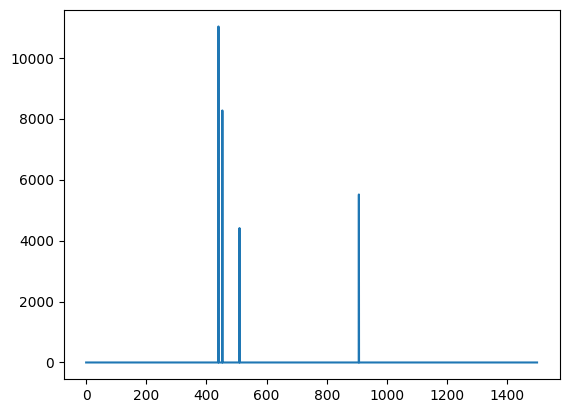

<Figure size 800x600 with 0 Axes>

In [17]:
#Exercise 1-3
import thinkdsp
import thinkplot
from IPython.display import Audio
cos_signal1 = thinkdsp.CosSignal(freq=440, amp=1.0, offset=0)
cos_signal2 = thinkdsp.CosSignal(freq=453, amp=0.75, offset=0)
sin_signal1 = thinkdsp.SinSignal(freq=510, amp=0.4, offset=0)
sin_signal2 = thinkdsp.SinSignal(freq=907, amp=0.5, offset=0)
mix = cos_signal1 + cos_signal2 + sin_signal1 + sin_signal2
wave = mix.make_wave(duration=2, start=0, framerate=11025)
spectrum = wave.make_spectrum()
spectrum.plot(high=1500)
thinkplot.show()
audio = Audio(data=wave.ys, rate=wave.framerate)
audio

#If you add signals that are not multiples of the fundamental, you get a more complex
#sound, effectively more than one note or harmony. In this case, one of the signals is only
#a little bit higher that the fundamental, creating a beating effect.




In [36]:
import thinkdsp
from IPython.display import Audio

def stretch(wave, factor):
     wave.ts *= factor
     wave.framerate /= factor
     return wave

cos_signal1 = thinkdsp.CosSignal(freq=440, amp=1.0, offset=0)
cos_signal2 = thinkdsp.CosSignal(freq=453, amp=0.75, offset=0)
mix = cos_signal1 + cos_signal2
wave = mix.make_wave(duration=2, start=0, framerate=11025)
audio = Audio(data=wave.ys, rate=wave.framerate)
audio

stretch(wave=wave, factor=2)
audio2 = Audio(data=wave.ys, rate=wave.framerate)
audio2




In [11]:
import numpy as np

def test(a, b, c, d):
    cycles = a * b + c / 0.3
    print(cycles)
    frac, _ = np.modf(cycles)
    print(frac)
    e = np.abs(frac - 0.5)
    print(e)

test(a=0.5, b=np.array([1,2,3,4,5,6,7,8,9]), c=2.7, d=4.3)



[ 9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5]
[5.00000000e-01 1.77635684e-15 5.00000000e-01 1.77635684e-15
 5.00000000e-01 1.77635684e-15 5.00000000e-01 1.77635684e-15
 5.00000000e-01]
[1.77635684e-15 5.00000000e-01 1.77635684e-15 5.00000000e-01
 1.77635684e-15 5.00000000e-01 1.77635684e-15 5.00000000e-01
 1.77635684e-15]


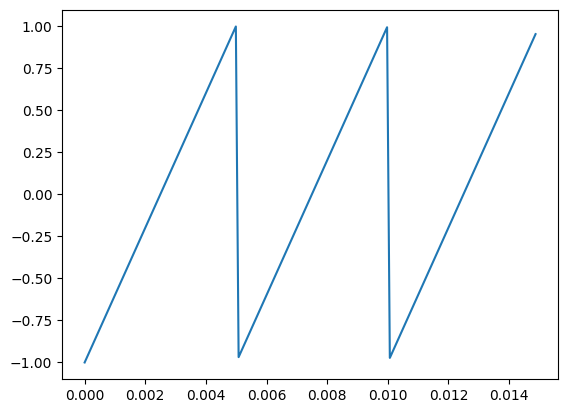

In [63]:
#Exercise 2-2

from thinkdsp import Sinusoid, PI2, normalize, unbias
class SawtoothSignal(Sinusoid):

    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / PI2
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(ys), self.amp)
        return ys

signal = SawtoothSignal(200)
wave = signal.make_wave(duration=0.5, start=0, framerate=11025)
signal.plot()
audio = Audio(data=wave.ys, rate=wave.framerate)
audio

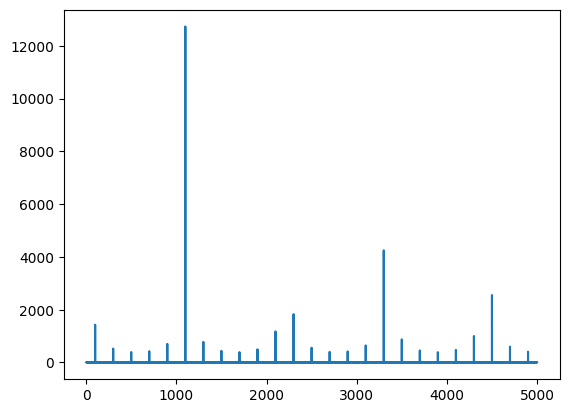

<Figure size 800x600 with 0 Axes>

In [72]:
# Exercise 2-3

from thinkdsp import SquareSignal

signal = SquareSignal(1100)
wave = signal.make_wave(duration=2, start=0, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()
thinkplot.show()
audio = Audio(data=wave.ys, rate=wave.framerate)
audio

# Using a framerate of 10000 for the wave, we can see from the spectrum 
# that some of the harmonics are aliased. E.g. there should be a harmonic at 5500 but it's 
# at 4500. There is none at 7700, presumably this has wrapped around to the one at about 100 Hz.
# The aliasing is audible as a low pitched harmonic set against the fundamental. we actually percieve
# this lower harmonic as the fundamental.




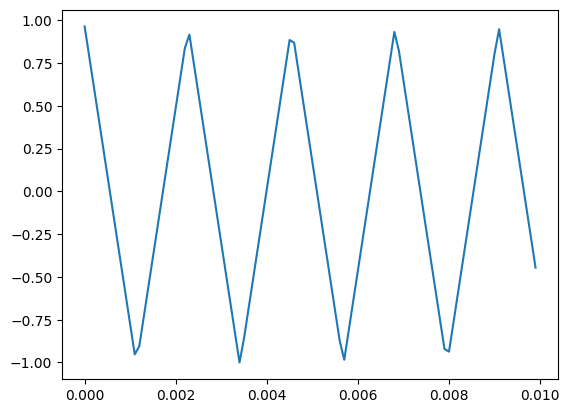

0.0 100.0 200.0 300.0
(3.375077994860476e-14+0j) (2.731170860095271+1.309292673139602j) (3.030509212162948+3.027978671395331j) (4.0616966529817145+6.733766188858302j)


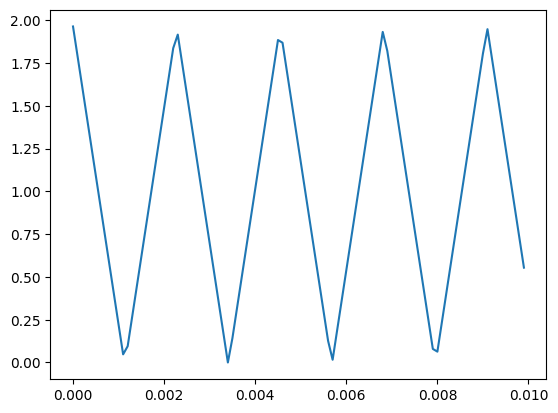

In [83]:
# Excercise 2-4

from thinkdsp import TriangleSignal
from matplotlib import pyplot

signal = TriangleSignal(440)
wave = signal.make_wave(duration=0.01, start=0, framerate=10000)
wave.plot()
pyplot.show()
spectrum = wave.make_spectrum()
print(spectrum.fs[0], spectrum.fs[1], spectrum.fs[2], spectrum.fs[3])
print(spectrum.hs[0], spectrum.hs[1], spectrum.hs[2], spectrum.hs[3])
spectrum.hs[0] = 100
wave2 = spectrum.make_wave()
wave2.plot()
pyplot.show()

# The value of spectrum.hs[0] is 3.375077994860476e-14+0j, so it has a
# small amplitude and a phase of 0.
# Setting spectrum.hs[0] to 100 causes the wave's amplitude to be entirely
# above 0, going up as high as 2. It never goes through 0. The new wave
# is vertically offset from the old one.
# The zero frequency component is the total of all the values in the signal,
# and if the signal is unbiased the zero frequency component is 0. In electrical
# signals, the zero frequency term is called the DC offset - a direct current offset
# aded to an AC signal.

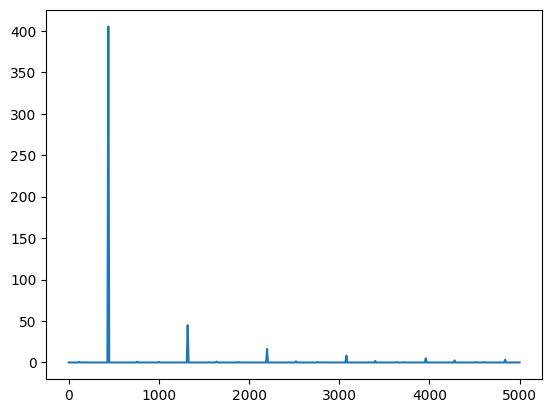

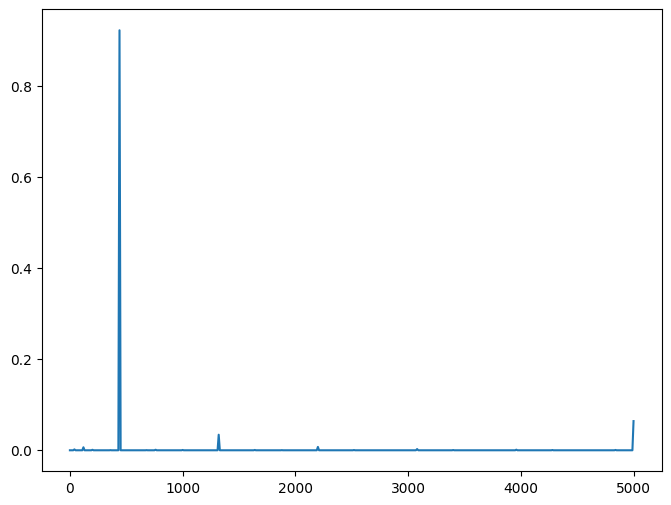

<Figure size 800x600 with 0 Axes>

In [142]:
# Exercise 2-5

def divide_spectrum(spectrum):
    spectrum.hs[0] = 0
    for idx in range(1, spectrum.hs.size - 1):
        spectrum.hs[idx] = spectrum.hs[idx] / spectrum.fs[idx]

        # A neater way of doing that loop would be
        # spectrum.hs[1:] /= spectrum.fs[1:]
    return spectrum

signal = TriangleSignal(440)
wave = signal.make_wave(duration=0.1, start=0, framerate=10000)
audio = Audio(data=wave.ys, rate=wave.framerate)
audio
spectrum = wave.make_spectrum()
spectrum.plot()
thinkplot.show()
spectrum = divide_spectrum(spectrum)
spectrum.plot()
thinkplot.show()
wave2 = spectrum.make_wave()
audio = Audio(data=wave2.ys, rate=wave.framerate)
audio

# Dividing the values of spectrum.hs by the corresponding values of .fs
# acts like a low pass filter by reducing the harmonics. 

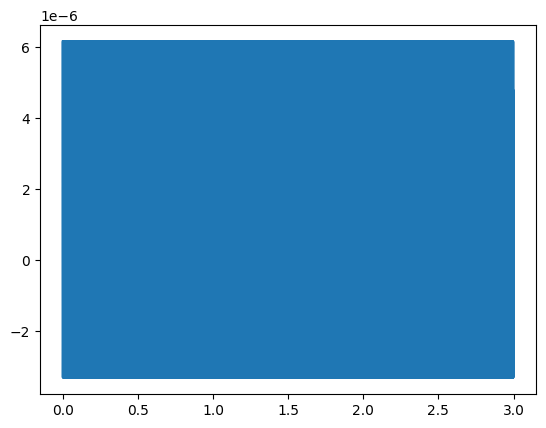

In [ ]:
# Exercise 2-6

from thinkdsp import CosSignal

def makeSignal(f):
    signal=CosSignal(freq=f, amp=1 / f**2)
    for i in range(2, 10):
        signal = signal + CosSignal(freq=f * i, amp=1 / (f * i)**2)
  
    return signal
 
signal = makeSignal(500)
wave = signal.make_wave(duration=3, start=0, framerate=10000)
wave.plot()
pyplot.show()
audio = Audio(data=wave.ys, rate=wave.framerate)
audio

